-- - Data Loading and Initial Exploration ---
FIRST 5 ROWS
     ID Delivery_person_ID  Delivery_person_Age  Delivery_person_Ratings  \
0  4607     INDORES13DEL02                   37                      4.9   
1  B379     BANGRES18DEL02                   34                      4.5   
2  5D6D     BANGRES19DEL01                   23                      4.4   
3  7A6A    COIMBRES13DEL02                   38                      4.7   
4  70A2     CHENRES12DEL01                   32                      4.6   

   Restaurant_latitude  Restaurant_longitude  Delivery_location_latitude  \
0            22.745049             75.892471                   22.765049   
1            12.913041             77.683237                   13.043041   
2            12.914264             77.678400                   12.924264   
3            11.003669             76.976494                   11.053669   
4            12.972793             80.249982                   13.012793   

   Delivery_location_longit

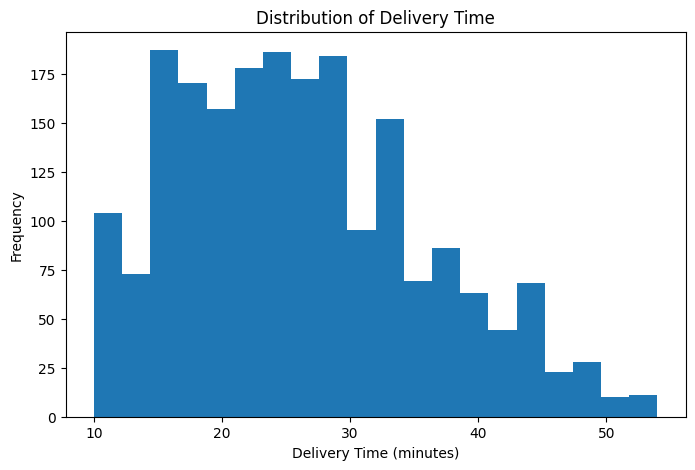

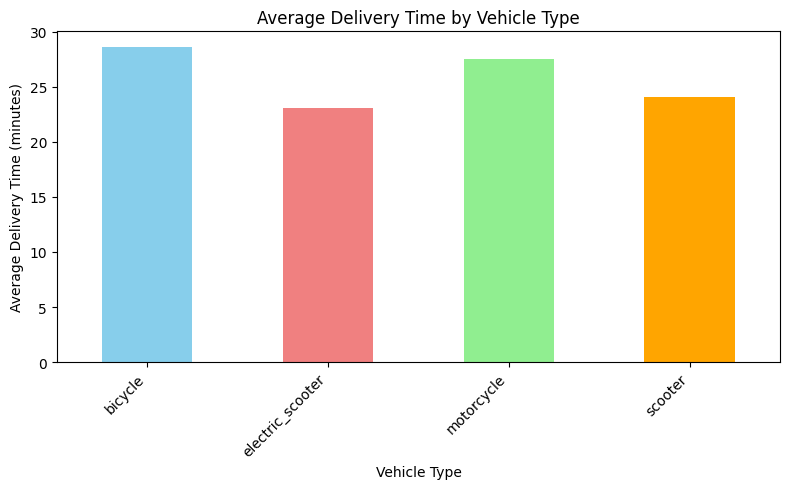

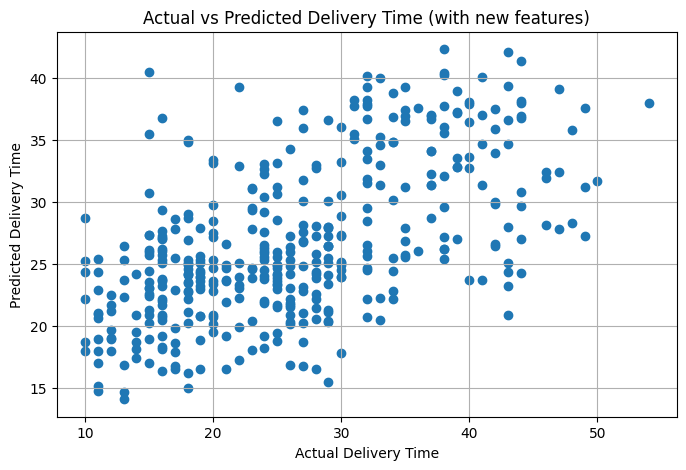


--- Model Training & Evaluation (WITHOUT new features) ---
MODEL PERFORMANCE (WITHOUT Distance, Weather, Traffic features)
Mean Absolute Error (MAE): 6.92
R2 Score: 0.23

--- Comparison of Model Performance ---
Model with Distance, Weather, Traffic features:
  MAE: 6.35
  R2 Score: 0.34

Model WITHOUT Distance, Weather, Traffic features:
  MAE: 6.92
  R2 Score: 0.23

Conclusion: Including Distance, Weather, and Traffic features IMPROVED the model's R2 score.


C:\Users\mithr\AppData\Local\Temp\ipykernel_11732\2048416052.py:217: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances.values, y=feature_importances.index, palette='viridis')


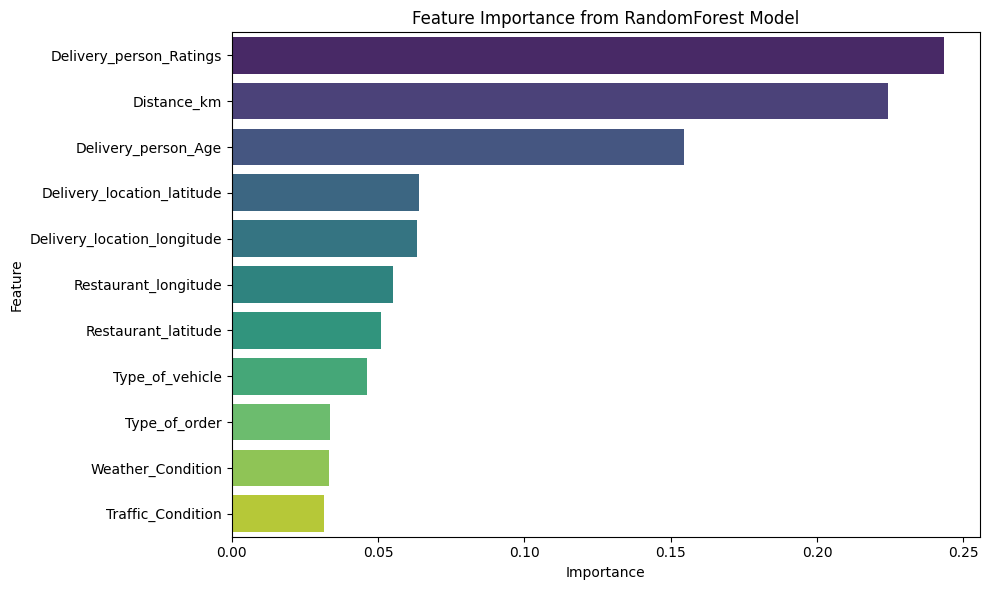

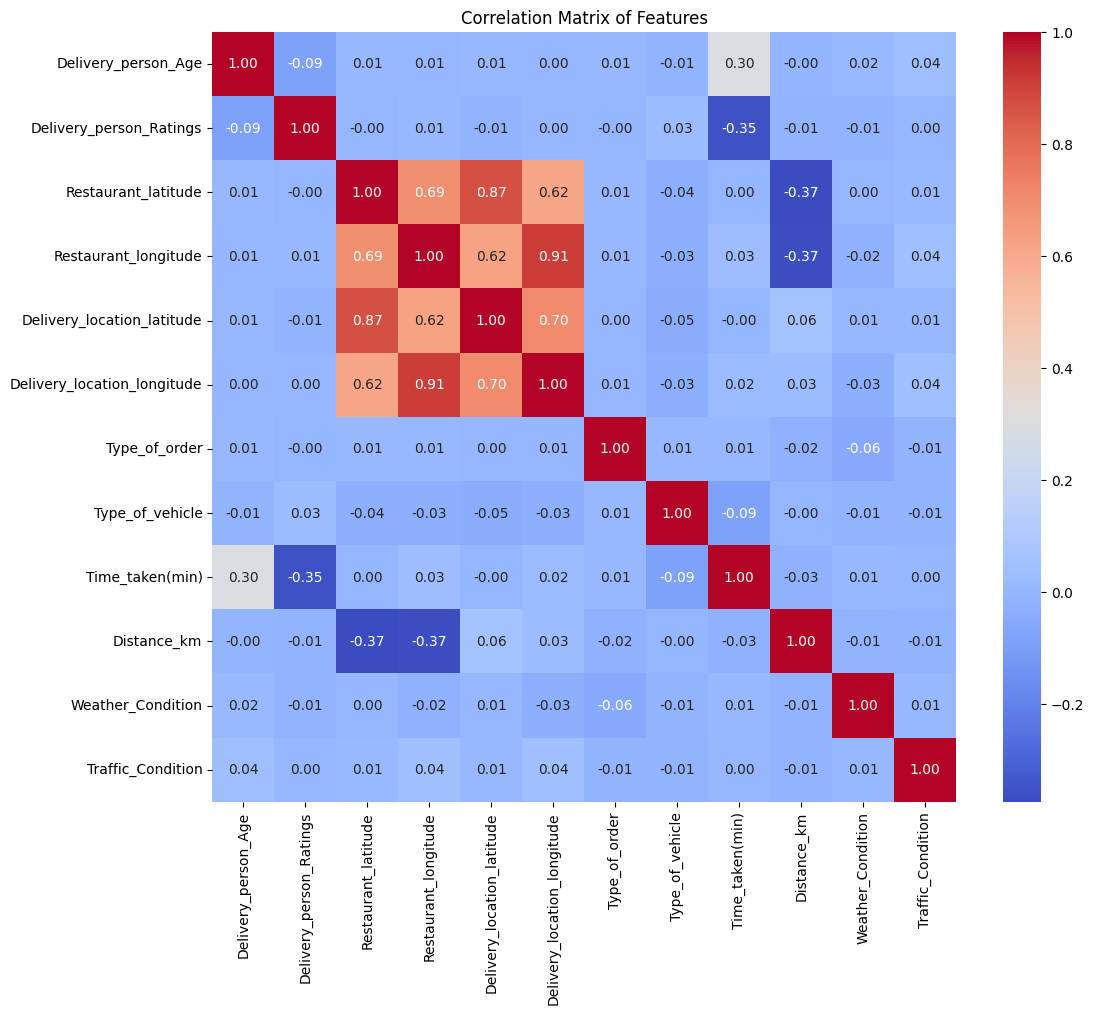

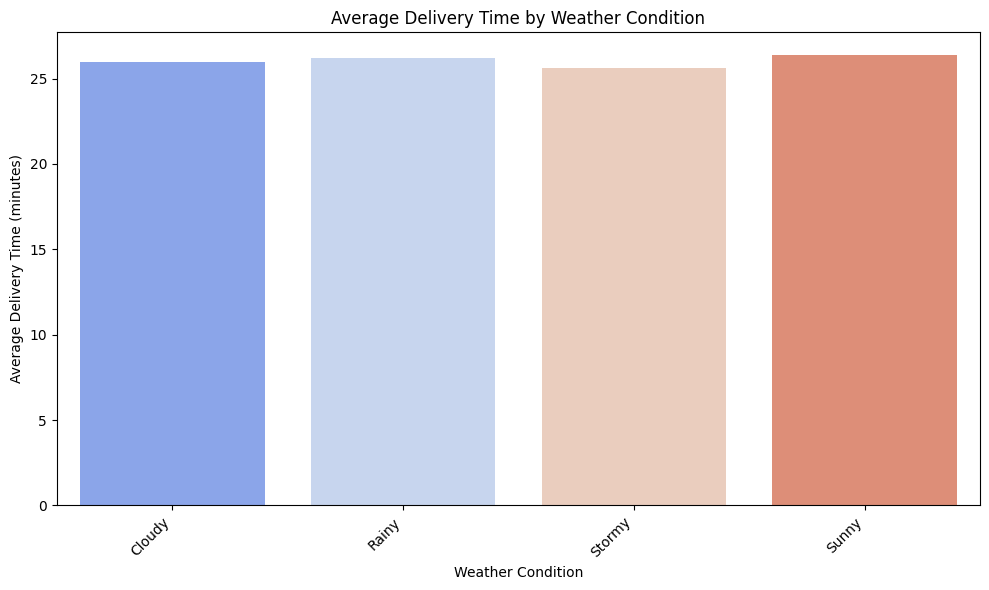

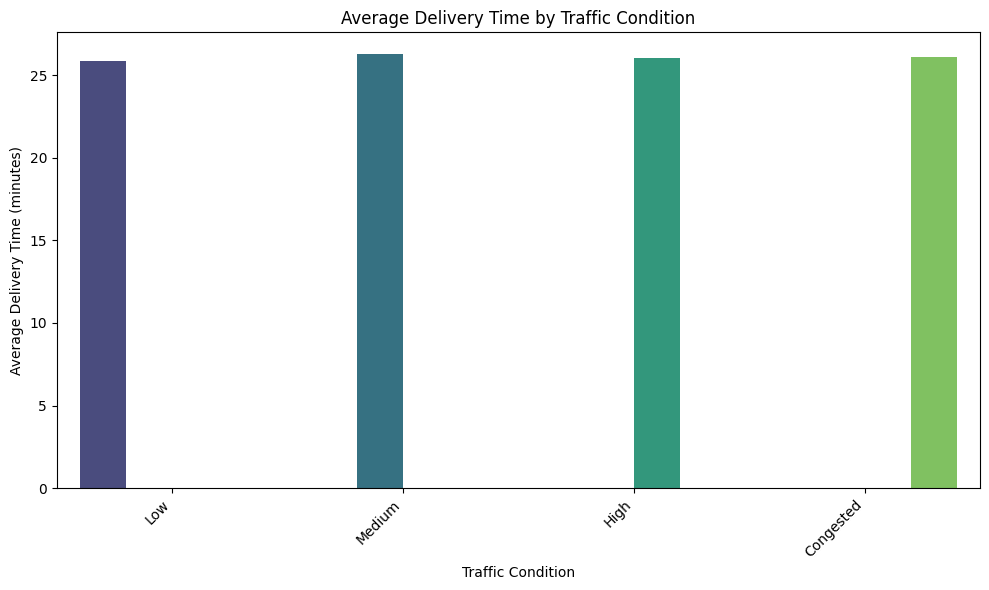

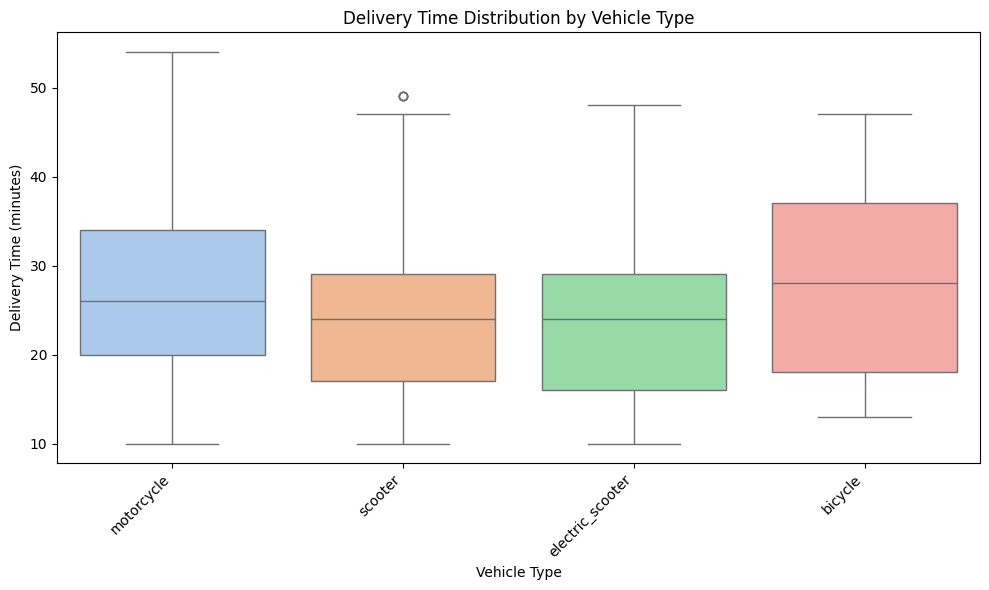

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
drive_file_path =(r"C:\Users\mithr\Downloads\food_dataset.csv")

print("-- - Data Loading and Initial Exploration ---")
df = pd.read_csv(drive_file_path)

print("FIRST 5 ROWS")
print(df.head())

print("\nDATASET SHAPE")
print(df.shape)

print("\nCOLUMN NAMES")
print(df.columns.tolist())

print("\nDATASET INFORMATION")
df.info()

print("\nMISSING VALUES")
print(df.isnull().sum())


df = df.drop(["ID", "Delivery_person_ID"], axis=1)

order_encoder = LabelEncoder()
vehicle_encoder = LabelEncoder()

df["Type_of_order"] = order_encoder.fit_transform(df["Type_of_order"])
df["Type_of_vehicle"] = vehicle_encoder.fit_transform(df["Type_of_vehicle"])

vehicle_type_mapping = {
    0: 'bicycle',
    1: 'electric_scooter',
    2: 'motorcycle',
    3: 'scooter'
}

def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
    distance = R * c
    return distance

df['Distance_km'] = df.apply(lambda row: haversine(
    row['Restaurant_latitude'], row['Restaurant_longitude'],
    row['Delivery_location_latitude'], row['Delivery_location_longitude']
), axis=1)

print("\nAdded 'Distance_km' feature.")

weather_conditions = ['Sunny', 'Cloudy', 'Rainy', 'Stormy']
df['Weather_Condition'] = np.random.choice(weather_conditions, size=len(df))

weather_encoder = LabelEncoder()
df['Weather_Condition'] = weather_encoder.fit_transform(df['Weather_Condition'])
print("Added placeholder 'Weather_Condition' feature.")

traffic_conditions = ['Low', 'Medium', 'High', 'Congested']
df['Traffic_Condition'] = np.random.choice(traffic_conditions, size=len(df))

traffic_encoder = LabelEncoder()
df['Traffic_Condition'] = traffic_encoder.fit_transform(df['Traffic_Condition'])
print("Added placeholder 'Traffic_Condition' feature.")


X = df.drop("Time_taken(min)", axis=1)
y = df["Time_taken(min)"]


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)


y_pred = model.predict(X_test)


mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nMODEL PERFORMANCE (with Distance, Weather, Traffic features)")
print("Mean Absolute Error (MAE):", round(mae, 2))
print("R2 Score:", round(r2, 2))


sample_data = X.iloc[[0]]

prediction = model.predict(sample_data)

print("\nPREDICTED DELIVERY TIME (with new features)")
print(round(prediction[0], 2), "minutes")


plt.figure(figsize=(8,5))
plt.hist(df["Time_taken(min)"], bins=20)

plt.title("Distribution of Delivery Time")
plt.xlabel("Delivery Time (minutes)")
plt.ylabel("Frequency")

plt.show()


plt.figure(figsize=(8,5))

grouped_data = df.groupby("Type_of_vehicle")["Time_taken(min)"].mean()

grouped_data.index = grouped_data.index.map(vehicle_type_mapping)

colors = ['skyblue', 'lightcoral', 'lightgreen', 'orange']

grouped_data.plot(kind="bar", color=colors)

plt.title("Average Delivery Time by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Average Delivery Time (minutes)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Delivery Time")
plt.ylabel("Predicted Delivery Time")
plt.title("Actual vs Predicted Delivery Time (with new features)")

plt.grid(True)

plt.show()


print("\n--- Model Training & Evaluation (WITHOUT new features) ---")
df_no_features = pd.read_csv(drive_file_path)

df_no_features = df_no_features.drop(["ID", "Delivery_person_ID"], axis=1)

order_encoder_no_feat = LabelEncoder()
vehicle_encoder_no_feat = LabelEncoder()

df_no_features["Type_of_order"] = order_encoder_no_feat.fit_transform(df_no_features["Type_of_order"])
df_no_features["Type_of_vehicle"] = vehicle_encoder_no_feat.fit_transform(df_no_features["Type_of_vehicle"])

X_no_features = df_no_features.drop("Time_taken(min)", axis=1)
y_no_features = df_no_features["Time_taken(min)"]

X_train_no_features, X_test_no_features, y_train_no_features, y_test_no_features = train_test_split(
    X_no_features,
    y_no_features,
    test_size=0.20,
    random_state=42
)

model_no_features = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model_no_features.fit(X_train_no_features, y_train_no_features)

y_pred_no_features = model_no_features.predict(X_test_no_features)

mae_no_features = mean_absolute_error(y_test_no_features, y_pred_no_features)
r2_no_features = r2_score(y_test_no_features, y_pred_no_features)

print("MODEL PERFORMANCE (WITHOUT Distance, Weather, Traffic features)")
print(f"Mean Absolute Error (MAE): {mae_no_features:.2f}")
print(f"R2 Score: {r2_no_features:.2f}")

print("\n--- Comparison of Model Performance ---")
print("Model with Distance, Weather, Traffic features:")
print(f"  MAE: {mae:.2f}")
print(f"  R2 Score: {r2:.2f}")
print("\nModel WITHOUT Distance, Weather, Traffic features:")
print(f"  MAE: {mae_no_features:.2f}")
print(f"  R2 Score: {r2_no_features:.2f}")

if r2 > r2_no_features:
    print("\nConclusion: Including Distance, Weather, and Traffic features IMPROVED the model's R2 score.")
elif r2 < r2_no_features:
    print("\nConclusion: Including Distance, Weather, and Traffic features DECREASED the model's R2 score.")
else:
    print("\nConclusion: Including Distance, Weather, and Traffic features did not significantly change the model's R2 score.")


feature_importances = pd.Series(model.feature_importances_, index=X.columns)
feature_importances = feature_importances.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances.values, y=feature_importances.index, palette='viridis')
plt.title('Feature Importance from RandomForest Model')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Features')
plt.show()

df['Weather_Condition_Name'] = weather_encoder.inverse_transform(df['Weather_Condition'])

average_time_by_weather = df.groupby('Weather_Condition_Name')['Time_taken(min)'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='Weather_Condition_Name', y='Time_taken(min)', data=average_time_by_weather, palette='coolwarm', hue='Weather_Condition_Name', legend=False)
plt.title('Average Delivery Time by Weather Condition')
plt.xlabel('Weather Condition')
plt.ylabel('Average Delivery Time (minutes)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

df = df.drop(columns=['Weather_Condition_Name'])
df['Traffic_Condition_Name'] = traffic_encoder.inverse_transform(df['Traffic_Condition'])

average_time_by_traffic = df.groupby('Traffic_Condition_Name')['Time_taken(min)'].mean().reset_index()

traffic_order = ['Low', 'Medium', 'High', 'Congested']
average_time_by_traffic['Traffic_Condition_Name'] = pd.Categorical(
    average_time_by_traffic['Traffic_Condition_Name'],
    categories=traffic_order,
    ordered=True
)
average_time_by_traffic = average_time_by_traffic.sort_values('Traffic_Condition_Name')

plt.figure(figsize=(10, 6))
sns.barplot(x='Traffic_Condition_Name', y='Time_taken(min)', data=average_time_by_traffic, palette='viridis', hue='Traffic_Condition_Name', legend=False)
plt.title('Average Delivery Time by Traffic Condition')
plt.xlabel('Traffic Condition')
plt.ylabel('Average Delivery Time (minutes)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

df = df.drop(columns=['Traffic_Condition_Name'])

df['Type_of_vehicle_Name'] = df['Type_of_vehicle'].map(vehicle_type_mapping)

plt.figure(figsize=(10, 6))
sns.boxplot(x='Type_of_vehicle_Name', y='Time_taken(min)', data=df, palette='pastel', hue='Type_of_vehicle_Name', legend=False)
plt.title('Delivery Time Distribution by Vehicle Type')
plt.xlabel('Vehicle Type')
plt.ylabel('Delivery Time (minutes)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

df = df.drop(columns=['Type_of_vehicle_Name'])